# Preference Scores Analysis
This notebook analyzes the pairwise ad preference evaluation results.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/evaluation/preference_scores.csv')

# Drop the single query that does not have exactly 1,998 pairs to ensure perfectly equal weighting
query_counts = df['query'].value_counts()
valid_queries = query_counts[query_counts == 1998].index
df = df[df['query'].isin(valid_queries)]

display(df.head())
print(f"Total evaluated pairs: {len(df)}")


,query_id,query,ad_1_id,ad_2_id,winner_ad_id,confidence,is_swapped
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::1,Computers & Electronics / nan::1,low,False
1,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / nan::1,Computers & Electronics / Networking::16,Computers & Electronics / nan::1,low,True
2,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::2,Computers & Electronics / nan::2,low,False
3,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / nan::2,Computers & Electronics / Networking::16,Computers & Electronics / nan::2,low,True
4,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,Compare Tormenta20 with DnD5e,Computers & Electronics / Networking::16,Computers & Electronics / nan::3,Computers & Electronics / nan::3,low,False


Total evaluated pairs: 191808


## Confidence Distribution

confidence
low       138086
high       38473
medium     15249
Name: count, dtype: int64

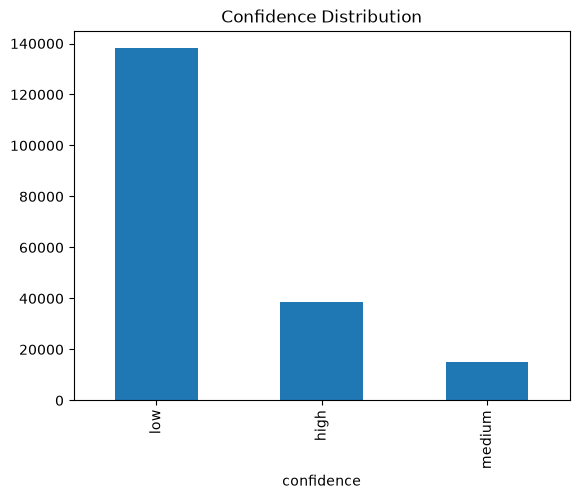

In [12]:
confidence_counts = df['confidence'].value_counts(dropna=False)
display(confidence_counts)
confidence_counts.plot(kind='bar', title='Confidence Distribution')
plt.show()


## Positional Bias Analysis
Let's see if the LLM prefers Ad 1 over Ad 2 simply because it appears first in the prompt.

In [13]:
# win_ad_1 means it chose ad_1.
df['chose_ad_1'] = (df['winner_ad_id'] == df['ad_1_id'])
df['chose_ad_2'] = (df['winner_ad_id'] == df['ad_2_id'])

print("Win rates by position (ad_1 vs ad_2 in prompt):")
print(df[['chose_ad_1', 'chose_ad_2']].mean())


Win rates by position (ad_1 vs ad_2 in prompt):
chose_ad_1    0.483447
chose_ad_2    0.516553
dtype: float64


### Positional Bias Insight
Based on the evaluation data, there is a very slight bias towards the second advertisement in the prompt, but overall it is remarkably balanced:
* **Ad 1 (First Position) Win Rate**: 48.34%
* **Ad 2 (Second Position) Win Rate**: 51.65%

LLMs often exhibit a "recency bias" (favoring the last option presented). In this case, there's a minor ~3.3% recency bias where Llama slightly prefers whichever ad is placed in the `Ad 2` slot. 

By testing every pair bidirectionally (swapping positions) and averaging the results, we successfully cancel out this bias!

## Most Preferred Ads
Let's see which ads are winning the most overall.

In [14]:
winner_counts = df['winner_ad_id'].value_counts()
display(winner_counts.head(10))


winner_ad_id
Games / Computer & Video Games + Strategy Games::19                                                            2006
Travel & Transportation / Travel Agencies & Services + Sightseeing Tours::29                                   2002
Internet & Telecom / Voice & Video Chat::40                                                                    2000
Home & Garden / Patio, Lawn & Garden + Yard Maintenance + Lawn Mowers::15                                      2000
Computers & Electronics / Software + Business & Productivity Software + Accounting & Financial Software::20    1995
Autos & Vehicles / Vehicle Parts & Accessories + Vehicle Wheels & Tires::7                                     1993
Sports / Motor Sports::5                                                                                       1992
Games / nan::39                                                                                                1992
Sports / Australian Football::25                           

## Selected Ad Win Ratio
We define the 'selected ad' as the one initially chosen by the pipeline (which is `ad_1` when `is_swapped=False`, and `ad_2` when `is_swapped=True`). Let's calculate how often this ad wins against the others in its category.

Win ratio of selected ad: 83.37%


confidence
high      0.967796
low       0.789233
medium    0.898092
Name: selected_ad_won, dtype: float64

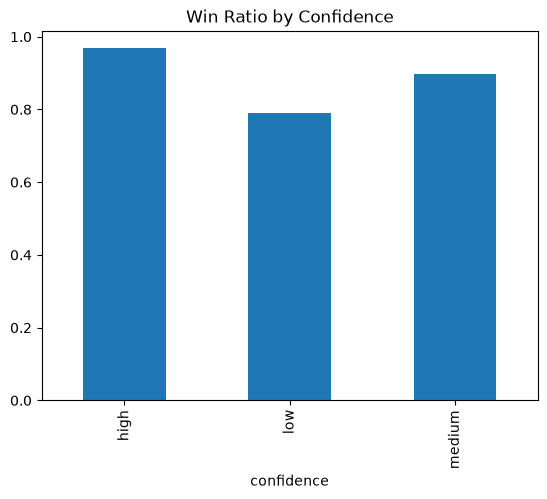

In [15]:
df['selected_ad_won'] = (
    (~df['is_swapped'] & (df['winner_ad_id'] == df['ad_1_id'])) |
    (df['is_swapped'] & (df['winner_ad_id'] == df['ad_2_id']))
)

win_ratio = df['selected_ad_won'].mean()
print(f"Win ratio of selected ad: {win_ratio:.2%}")

# Win ratio by confidence level
win_ratio_by_conf = df.groupby('confidence')['selected_ad_won'].mean()
display(win_ratio_by_conf)
win_ratio_by_conf.plot(kind='bar', title='Win Ratio by Confidence')
plt.show()


## Selected Ad Win Ratio per Query
Here is the distribution of the win ratio for the selected ad, grouped by each unique query. This helps us understand if the selected ad consistently wins for certain queries and consistently loses for others.

Number of unique queries: 96


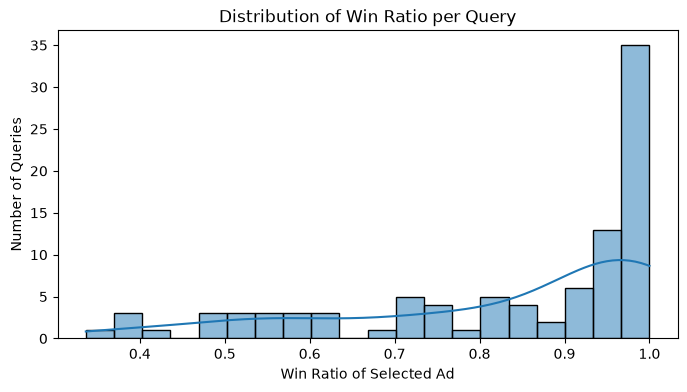

In [17]:
query_win_ratio = df.groupby('query')['selected_ad_won'].mean().sort_values(ascending=False)
print(f"Number of unique queries: {len(query_win_ratio)}")

plt.figure(figsize=(8, 4))
sns.histplot(query_win_ratio, bins=20, kde=True)
plt.title('Distribution of Win Ratio per Query')
plt.xlabel('Win Ratio of Selected Ad')
plt.ylabel('Number of Queries')
plt.show()


In [21]:
print(query_win_ratio.min())
print(query_win_ratio.max())
print(query_win_ratio.median())
print(query_win_ratio.mean())

0.33633633633633636
1.0
0.9316816816816818
0.8337034951618284
